In [1]:
%load_ext autoreload
%autoreload 2

from datasets import load_dataset
import pandas as pd
from dotenv import load_dotenv
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns 
from numpy.random import randint
load_dotenv()

import sys
sys.path.append("../..")
from src.utils.vlm_utils import display_image, do_image_analysis, check_screenshot_validity, do_ocr

dataset = load_dataset("Vokturz/sourceforge-app-screenshots")

/home/pudu/repos/desktop-screenshots-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = dataset['train'].to_pandas()
valid_df = pd.read_json('../data/validation_results.jsonl', lines=True)
df = df.merge(valid_df, on="slug")
df

,slug,url,title,registration_date,description,is_mirror,topics,image,width,height,is_valid
0,boot-repair,https://sourceforge.net/p/boot-repair/,boot-repair,2011-08-11,See https://sourceforge.net/p/boot-repair/home,False,[],{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,411,267,True
1,codeblocks,https://sourceforge.net/p/codeblocks/,Code::Blocks,2004-12-20,"Code::Blocks is a free, open-source, cross-pla...",False,"[integrated-development-environments-ide, buil...",{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,635,480,True
2,crystaldiskinfo,https://sourceforge.net/p/crystaldiskinfo/,CrystalDiskInfo,2023-08-11,A HDD/SSD utility software which supports a pa...,False,"[disk-space-analyzers, hard-disk-health-check]",{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,1012,952,True
3,hwinfo,https://sourceforge.net/p/hwinfo/,HWiNFO,2023-10-05,Professional System Information and Diagnostic...,False,"[hardware-monitoring, disk-space-analyzers, ha...",{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,1126,678,True
4,infrarecorder,https://sourceforge.net/p/infrarecorder/,InfraRecorder,2006-08-18,InfraRecorder is a high quality CD/DVD burning...,False,"[cd-ripping, dvd-burners, cd-burners]",{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,905,647,False
...,...,...,...,...,...,...,...,...,...,...,...
1388,youtube-vanced-pc,https://sourceforge.net/p/youtube-vanced-pc/,YouTube Vanced PC,2018-09-12,YouTube Vanced PC is a workaround solution tha...,False,[youtube-downloaders],{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,717,600,True
1389,zbar.mirror,https://sourceforge.net/projects/zbar.mirror/,ZBar,2024-10-31,ZBar is an open source software suite for read...,True,[barcode-scanners],{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,428,281,True
1390,zekr,https://sourceforge.net/p/zekr/,Zekr: Multimedia Quran Study Software,2005-01-10,Zekr is an open source Quran study software fo...,False,"[religion-and-philosophy, education]",{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,640,436,True
1391,zxw-download,https://sourceforge.net/p/zxw-download/,ZXW Download,2023-10-15,"ZXWSoft3.34_ALL_Package(41.6M)- – May 28, 202...",False,[],{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1000,1000,True


In [3]:
df.groupby('is_mirror')['is_valid'].value_counts(normalize=True)

is_mirror  is_valid
False      True        0.862850
           False       0.137150
True       True        0.791277
           False       0.208723
Name: proportion, dtype: float64

In [4]:
# Count slugs per topic
valid_topic_counts = Counter()
invalid_topic_counts = Counter()
for idx, row in df.iterrows():
    if row.is_valid:
        for topic in row.topics:
            valid_topic_counts[topic] += 1
    else:
        for topic in row.topics:
            invalid_topic_counts[topic] += 1
    

valid_topics_df = pd.DataFrame(valid_topic_counts.items(), columns=['topic', 'count'])
valid_topics_df['is_valid'] = True
invalid_topics_df = pd.DataFrame(invalid_topic_counts.items(), columns=['topic', 'count'])
invalid_topics_df['is_valid'] = False
topics_df = pd.concat([valid_topics_df, invalid_topics_df])
topics_df

,topic,count,is_valid
0,integrated-development-environments-ide,28,True
1,build-tools,15,True
2,debuggers,11,True
3,compilers,9,True
4,user-interface-ui,26,True
...,...,...,...
206,task-runners,1,False
207,robotic-process-automation-rpa,1,False
208,systems-administration,1,False
209,cgi-scripts,1,False


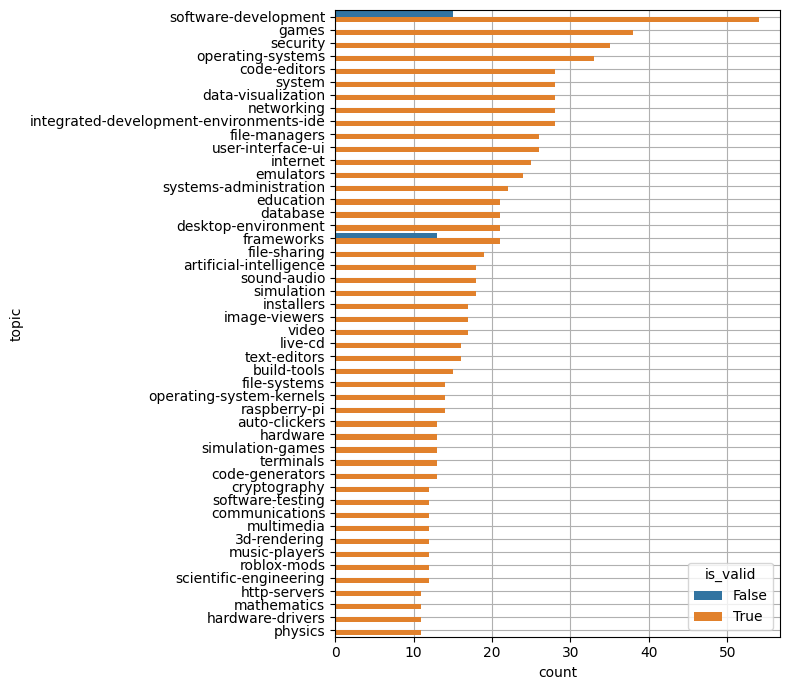

In [6]:
fig, ax= plt.subplots(figsize=(8,7))
N = 50
sns.barplot(topics_df.sort_values("count", ascending=False).head(N), y="topic", x="count", hue='is_valid', ax=ax)
ax.set_axisbelow(True)
plt.grid()
plt.tight_layout()


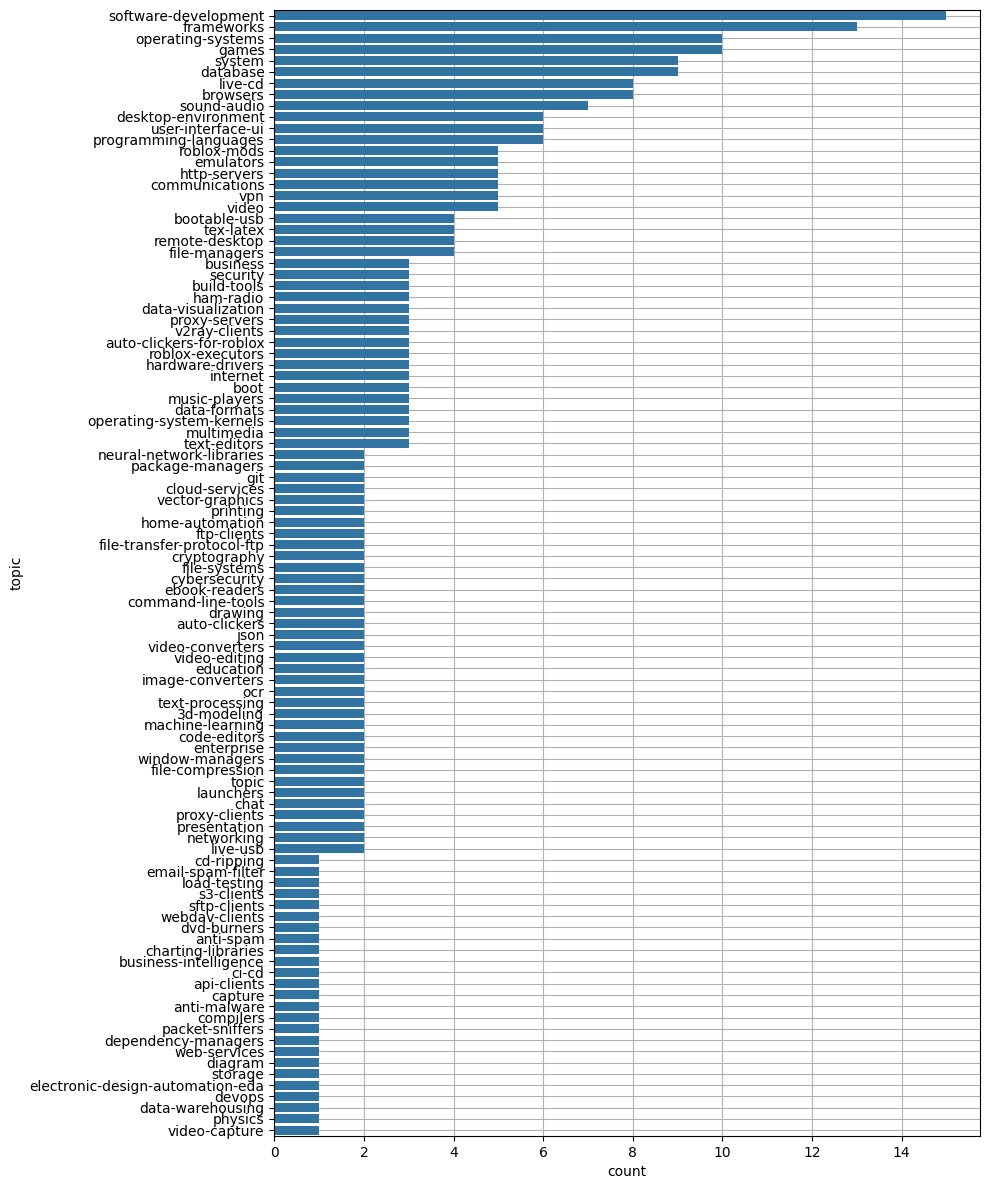

In [7]:
fig, ax= plt.subplots(figsize=(10,12))
N = 100
sns.barplot(invalid_topics_df.sort_values("count", ascending=False).head(N), y="topic", x="count", ax=ax)
ax.set_axisbelow(True)
plt.grid()
plt.tight_layout()


In [8]:
invalid_dataset = dataset['train'].filter(lambda x : not valid_df.set_index('slug').loc[x['slug']]['is_valid']) 
invalid_dataset

Dataset({
    features: ['slug', 'url', 'title', 'registration_date', 'description', 'is_mirror', 'topics', 'image', 'width', 'height'],
    num_rows: 237
})

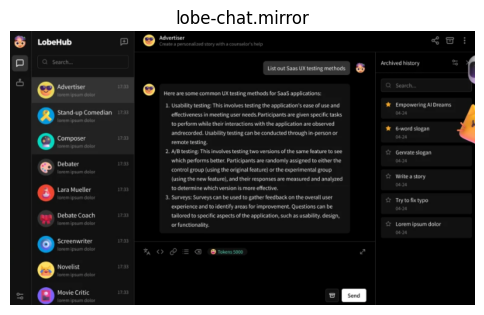

LobeChat, unlock the superpower of your brain. Pioneering the new age of thinking and creating. Built for you, the Super Individual. LobeChat supports file upload and knowledge base functionality. You can upload various types of files including documents, images, audio, and video, as well as create knowledge bases, making it convenient for users to manage and search for files. Additionally, you can utilize files and knowledge base features during conversations, enabling a richer dialogue experience. In the continuous development of LobeChat, we deeply understand the importance of diversity in model service providers for meeting the needs of the community when providing AI conversation services. Therefore, we have expanded our support to multiple model service providers, rather than being limited to a single one, in order to offer users a more diverse and rich selection of conversations.


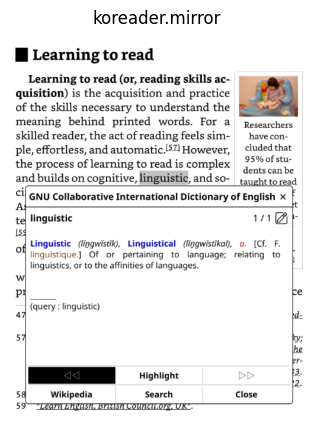

KOReader is a document viewer for E Ink devices. Supported fileformats include EPUB, PDF, DjVu, XPS, CBT, CBZ, FB2, PDB, TXT, HTML, RTF, CHM, DOC, MOBI and ZIP files. It’s available for Kindle, Kobo, PocketBook, Android and desktop Linux. Runs on embedded devices (Cervantes, Kindle, Kobo, PocketBook, reMarkable), Android and Linux computers. Developers can run a KOReader emulator in Linux and MacOS. Multi-lingual user interface with a highly customizable reader view and many typesetting options. You can set arbitrary page margins, override line spacing and choose external fonts and styles. It has multi-lingual hyphenation dictionaries bundled into the application. Custom UI without animation, with paginated menus, adjustable text contrast, and easy zoom to fit content or page in paged media. Look up words with StarDict dictionaries / Wikipedia, add your own online OPDS catalogs and RSS feeds, share ebooks with other KOReader devices wirelessly.


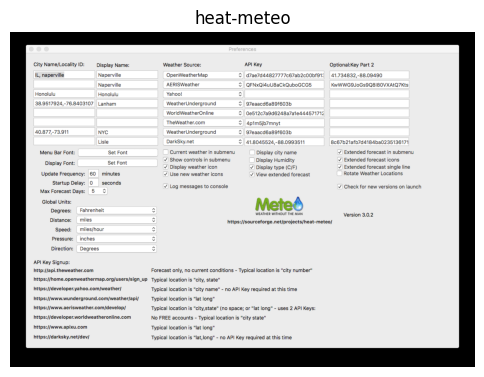

Meteorologist is a free weather program for OS X.  It allows users total control over their weather viewing, including simultaneous interlaced weather reports from multiple weather servers, multiple weather locations, weather alerts and much more.


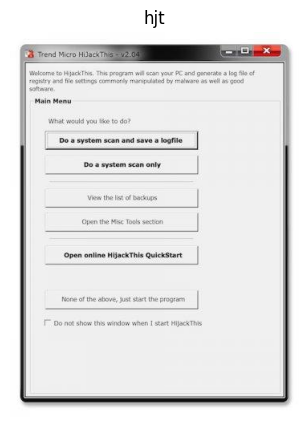

-- WARNING --

HiJackThis is an inactive project and it is not updated anymore. You may want to look at the existent unofficial forks though:

https://github.com/dragokas/hijackthis/

--

HijackThis is a free utility that generates an in depth report of registry and file settings from your computer. HijackThis scan results make no separation between safe and unsafe settings , which gives you the ability to selectively remove items from your machine. In addition to scan and remove capabilities, HijackThis comes with several useful tools to manually remove malware from your computer. However, HijackThis does not make value based calls between what is considered good or bad. It is important to exercise caution and avoid making changes to your computer settings, unless you have expert knowledge. Source code is available SourceForge, under Code and also as a zip file under Files.


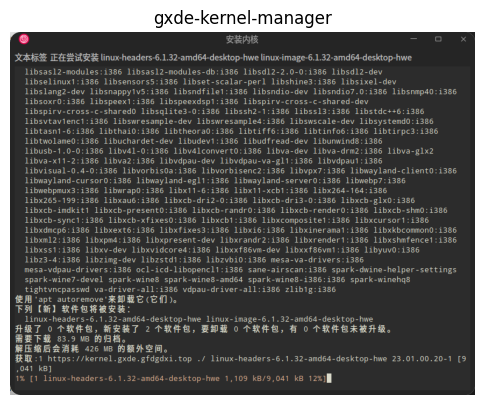

GXDE Kernel Manager is a kernel manager to allow users to install or remove kernels easily.

Source/Download: https://github.com/GXDE-OS/gxde-kernel-manager

QQ: 881201853


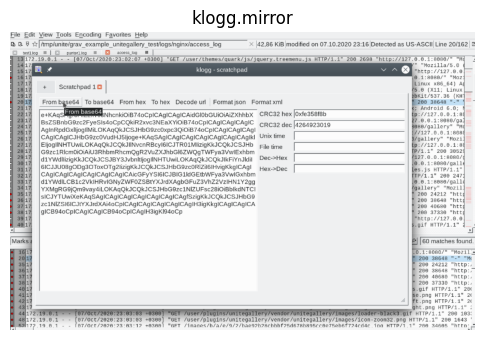

Klogg is an open source multi-platform GUI application to search through all kinds of text log files using regular expressions. It has started as fork of glogg project created by Nicolas Bonnefon and has evolved into a separate project with a lot of new features and improvements.


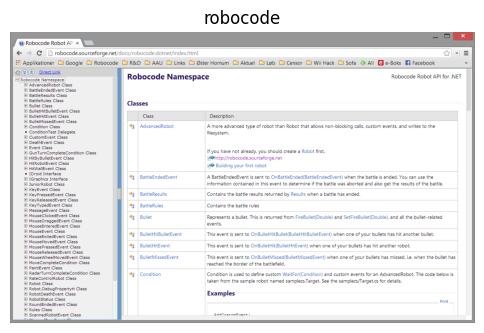

Robocode is a programming game, where the goal is to develop a robot battle tank to battle against other tanks with Java. The robot battles are running in real-time and on-screen. The motto of Robocode is: Build the best, destroy the rest!


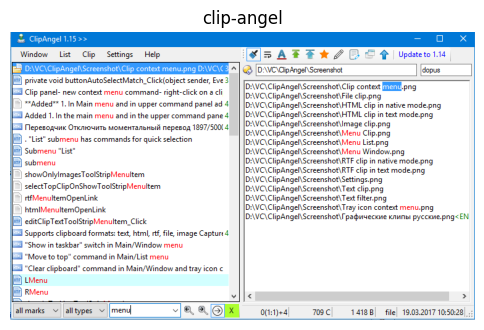

This program belongs to class "Clipboard Manager". It captures many clipboard objects and allows user to select and paste one in any program. Inspired by analogs: ClipDiary, Ditto, AceText. Main priorities: usability, compatibility, reliability.
Requires .Net Framework 4.52+ (Windows Vista+/Server 2008+)


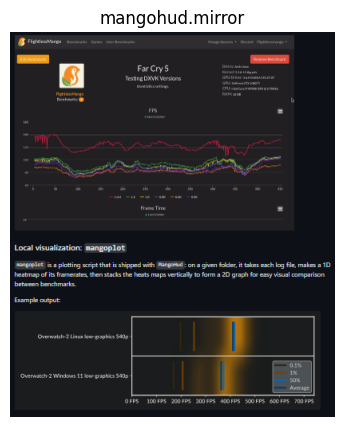

A Vulkan and OpenGL overlay for monitoring FPS, temperatures, CPU/GPU load and more. mangoplot is a plotting script that is shipped with MangoHud: on a given folder, it takes each log file, makes a 1D heatmap of its framerates, then stacks the heat maps vertically to form a 2D graph for easy visual comparison between benchmarks.


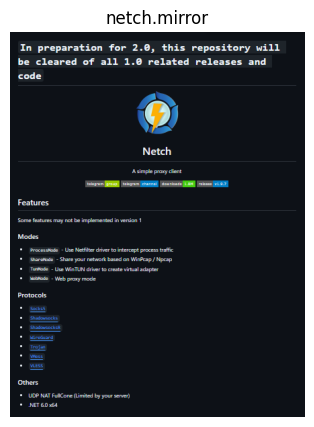

Netch is an open-source Windows proxy client written in C#, designed for both gaming and general web acceleration. It supports various proxy protocols—Socks5, Shadowsocks, ShadowsocksR, Trojan, VMess, VLESS—and multiple operation modes including process-level interception, shared network, tun/tap virtual adapters, and web proxy. Extensively configurable, it’s ideal for users managing traffic routing per application.


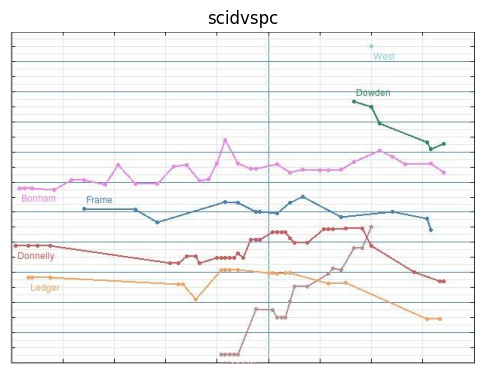

"Shane's Chess Information Database" is a huge chess toolkit with extensive database, analysis and chess-playing features.

Scid vs. PC is a usability and bug-fix fork of Scid.  It has many interface fixes and improvements, and is fully compatible with Scid's .si4 databases. New features include a rewritten Gamelist, Computer Tournament, and FICS, Tree, Book and Graph improvements.




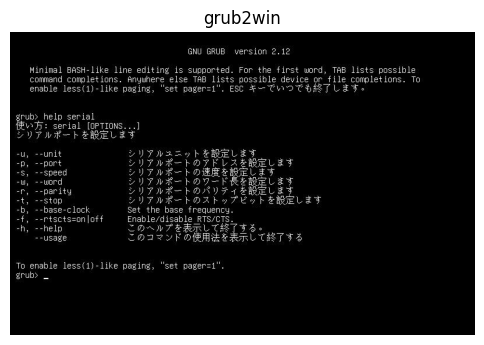

Safely multiboot Windows and Linux systems.

Grub2Win is a  robust Windows application. 
Configure Grub boot screens and options directly from Windows.

Completely free and open source. 
All modules are SSL signed for your security.

Use your own .jpg files to create and customize background wallpaper.

Everything installs to a 30 MB directory on your Windows C: drive.  

Automatically generates config files for PhoenixOS, Android, Ubuntu, Debian, Suse, Fedora, Manjaro, Mint, OpenCore, POSROG and Windows.  You can import Linux config files for Chrome and most other distributions.

Supports Windows 11 and 10 machines running 64 bit EFI firmware.

For older Windows and BIOS firmware machines, the installer will automatically download and install Grub2Win Legacy.

Grub2Win began in 2010 and has been downloaded more than 1.8 million times in 180 countries.

If you like Grub2Win, please consider a small donation to be used for hardware and testing.


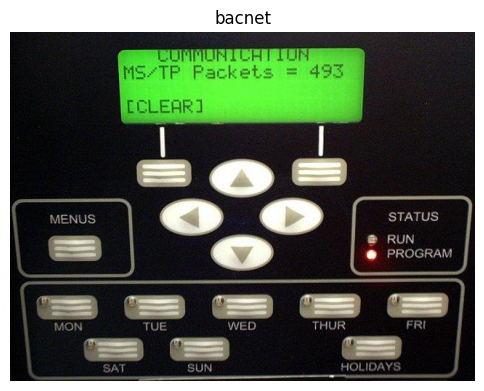

BACnet - Data Communication Protocol for Building Automation and Control Networks - see www.bacnet.org. This BACnet library provides an application layer, network layer and MAC layer communications services for Win32, Linux, RTOS, or microcontroller.


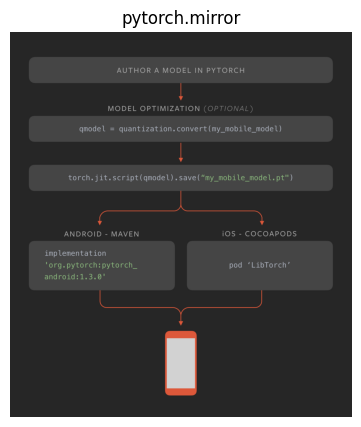

PyTorch is a Python package that offers Tensor computation (like NumPy) with strong GPU acceleration and deep neural networks built on tape-based autograd system. This project allows for fast, flexible experimentation and efficient production.PyTorch consists of torch (Tensor library), torch.autograd (tape-based automatic differentiation library), torch.jit (a compilation stack [TorchScript]), torch.nn (neural networks library), torch.multiprocessing (Python multiprocessing), and torch.utils (DataLoader and other utility functions). PyTorch can be used as a replacement for Numpy, or as a deep learning research platform that provides optimum flexibility and speed.


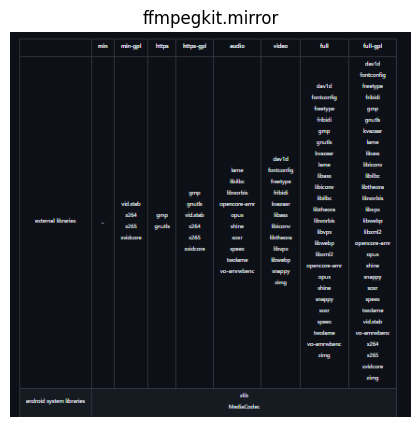

FFmpegKit is a collection of tools to use FFmpeg in Android, iOS, Linux, macOS, tvOS, Flutter and React Native applications. It includes scripts to build FFmpeg native libraries, a wrapper library to run FFmpeg/FFprobe commands in applications and 8 prebuilt binary packages available at Github, Maven Central, CocoaPods, pub and npm. All scripts support additional options to enable optional libraries and disable platform architectures. FFmpegKit is a wrapper library that allows you to easily run FFmpeg/FFprobe commands in applications. It provides additional features on top of FFmpeg to enable platform-specific resources, control how commands are executed and how the results are handled. There are eight different ffmpeg-kit packages distributed on Github, Maven Central, CocoaPods, pub and npm. Below you can see which system libraries and external libraries are enabled in each one of them.


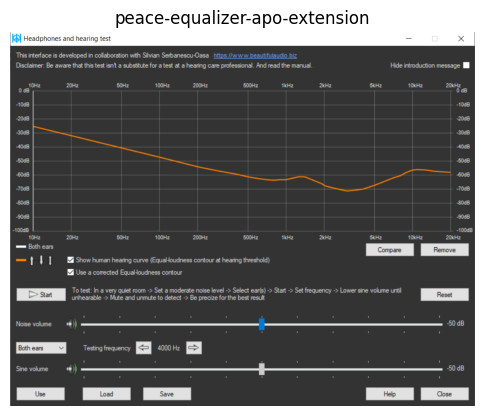

Before reading on, note there's scam website called 'peaceequalizer,com'. Only this site here on SourceForge is the actual website by me, Peter Verbeek.

Peace equalizer is a Windows PC interface for Equalizer APO http://sourceforge.net/projects/equalizerapo. Besides an system-wide audio equalizer on your Windows PC, Peace has an effects panel for balance, crossfeeding, delay, etc., a graph window and much more.

In short: Peace is an equalizer and audio mixer for all your PC software on any Windows version from Vista to 11.

Your configuration (e.g. EQ, preset, profile) can be saved and activated again by 1 click, hotkey, tray or desktop shotcut.

Install by running downloaded PeaceSetup.exe. Equalizer APO has to be installed first. After a Windows update a re-install of Equalizer APO might be needed.

Also, all Peace apps have a code signing certificate by Certum, Asseco.

YouTubers: Please mention Peace Equalizer in your video description.

Thanks to all contributors.


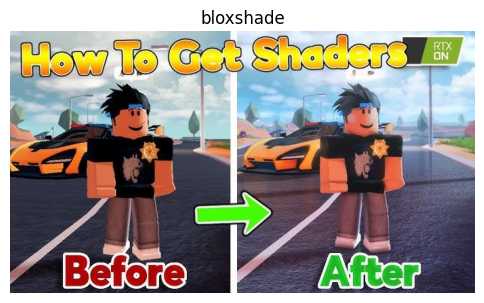

Improve Roblox with shaders. Download jpg. Installer source code. If you're interested in checking out the source code, you can check it out at GitHub.



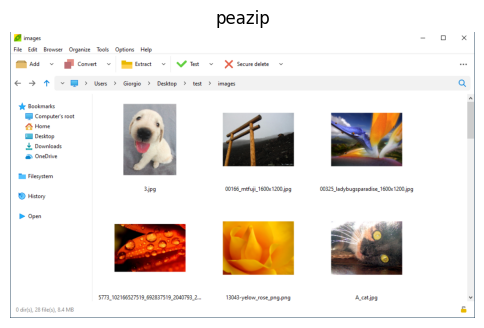

PeaZip is a free archiver tool. The application provides an unified, natively portable, cross-platform file manager and archive manager GUI for many Open Source technologies like 7-Zip, FreeArc, PAQ, UPX.

Create: 7Z, ARC, Brotl, BZip, GZip, PEA, TAR, WIM, XZ, ZPAQ, ZIP, Zstandard files and more

Open and extract 200+ file types: ACE, CAB, DEB, ISO, RAR, ZIPX and more

Features of PeaZip includes extract, create and convert multiple archives at once, create self-extracting archives (sfx), split files, strong encryption with two factor authentication, encrypted password manager, secure deletion, find duplicate files, calculate hashes, export task definition as command line script.


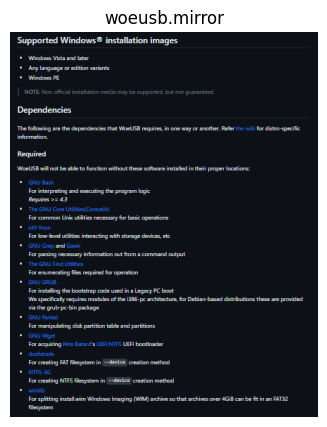

A Microsoft Windows® USB installation media preparer for GNU+Linux.


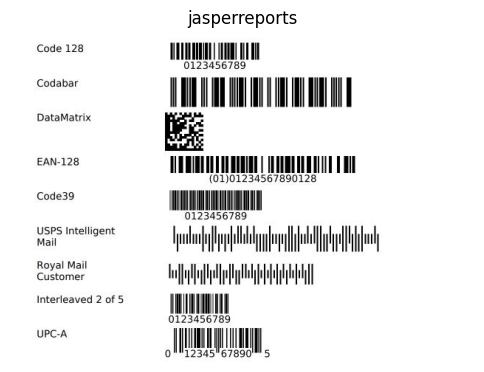

JasperReports Library is the world's most popular open source business intelligence and reporting engine.
It is entirely written in Java and it is able to use data coming from any kind of data source and produce pixel-perfect documents that can be viewed, printed or exported in a variety of document formats including HTML, PDF, Excel, OpenOffice and Word.

The project is also available at:
https://github.com/TIBCOSoftware/jasperreports

Jaspersoft Studio is the open source report designer for the JasperReports Library.
https://community.jaspersoft.com/project/jaspersoft-studio

JasperReports Server is the most popular open source interactive reporting and analytics server built-on JasperReports Library.
https://community.jaspersoft.com/project/jasperreports-server

JasperReports IO is for reporting and data visualization in a world of cloud, microservices, and DevOps.
https://community.jaspersoft.com/project/jasperreports-io



In [10]:
# We have some false-negatives, but I can live with that
N = 20
sample = randint(0, len(invalid_dataset), N)
for example in invalid_dataset.select(sample):
    display_image(example, figsize=(6,5))
    print(example['description'])